importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns 

Matplotlib is building the font cache; this may take a moment.


CHARGEMENT DU DATASET

In [2]:
df = pd.read_csv('..\\data\\raw\\AIML Dataset.csv')

Inspection de la structure

In [3]:
#taille du dataset
print("Taille du dataset:", df.shape)

Taille du dataset: (6362620, 11)


In [5]:
#types de variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [6]:
#aperçu du dataset
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [ ]:
#statistiques descriptives
df.drop(columns=["type", "nameOrig", "nameDest", "isFlaggedFraud", "isFraud"]).describe().astype(float)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,"6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00"
mean,243.40,"179,861.90","833,883.10","855,113.67","1,100,701.67","1,224,996.40"
std,142.33,"603,858.23","2,888,242.67","2,924,048.50","3,399,180.11","3,674,128.94"
min,1.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,"13,389.57",0.00,0.00,0.00,0.00
50%,239.00,"74,871.94","14,208.00",0.00,"132,705.66","214,661.44"
75%,335.00,"208,721.48","107,315.18","144,258.41","943,036.71","1,111,909.25"
max,743.00,"92,445,516.64","59,585,040.37","49,585,040.37","356,015,889.35","356,179,278.92"


Nettoyage et qualité des données


In [13]:
#nombres de valeurs manquantes
print("nombre de valeurs manquantes:", df.isnull().sum().sum())

nombre de valeurs manquantes: 0


In [14]:
#nombre de valeurs doubles
print("nombre de valeurs doubles:", df.duplicated().sum())

nombre de valeurs doubles: 0


In [15]:
#conversion de la variable type en variable catégorielle
df['type'] = df['type'].astype('category')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int64   
 1   type            category
 2   amount          float64 
 3   nameOrig        str     
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        str     
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         int64   
 10  isFlaggedFraud  int64   
dtypes: category(1), float64(5), int64(3), str(2)
memory usage: 618.7 MB


Analyse univariée

analyse de la varible cible 

In [ ]:
#nombre de fraudes vs non fraudes
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [17]:
#pourcentage des fraudes vs non fraudes
df["isFraud"].value_counts(normalize=True)*100

isFraud
0   99.87
1    0.13
Name: proportion, dtype: float64

<Axes: title={'center': 'Transactions Frauduleuses vs Non-Frauduleuses'}, xlabel='isFraud'>

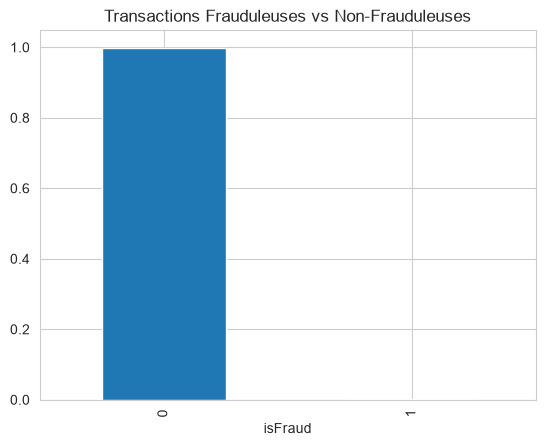

In [97]:
#graphique des fraudes vs non fraudes
df["isFraud"].value_counts(normalize=True).plot(kind='bar', title='Transactions Frauduleuses vs Non-Frauduleuses')

analyse de la variable "type"


In [22]:
#pourcentage des types de transactions
df["type"].value_counts(normalize=True)*100

type
CASH_OUT   35.17
PAYMENT    33.81
CASH_IN    21.99
TRANSFER    8.38
DEBIT       0.65
Name: proportion, dtype: float64

<Axes: title={'center': 'Type de transaction'}, xlabel='type'>

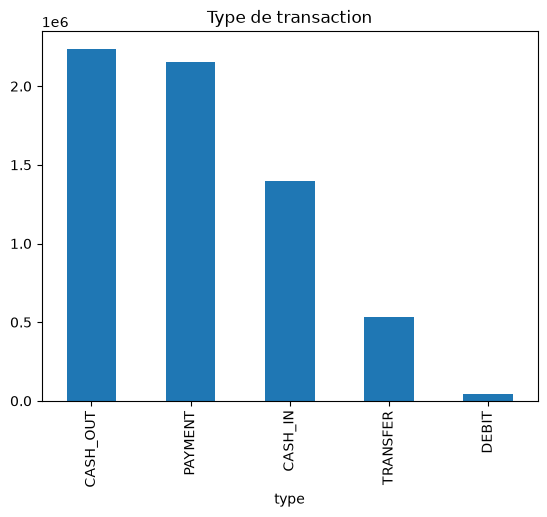

In [23]:
#graphiques des types de transactions
df["type"].value_counts().plot(kind='bar', title='Type de transaction')

#analyse de la variable "nameOrig"

In [24]:
#nombre des comptes d'origine
df["nameOrig"].value_counts()

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

analyse de la variable "nameDest"


In [25]:
#nombre des comptes de destination
df["nameDest"].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

analyse de la variable amount

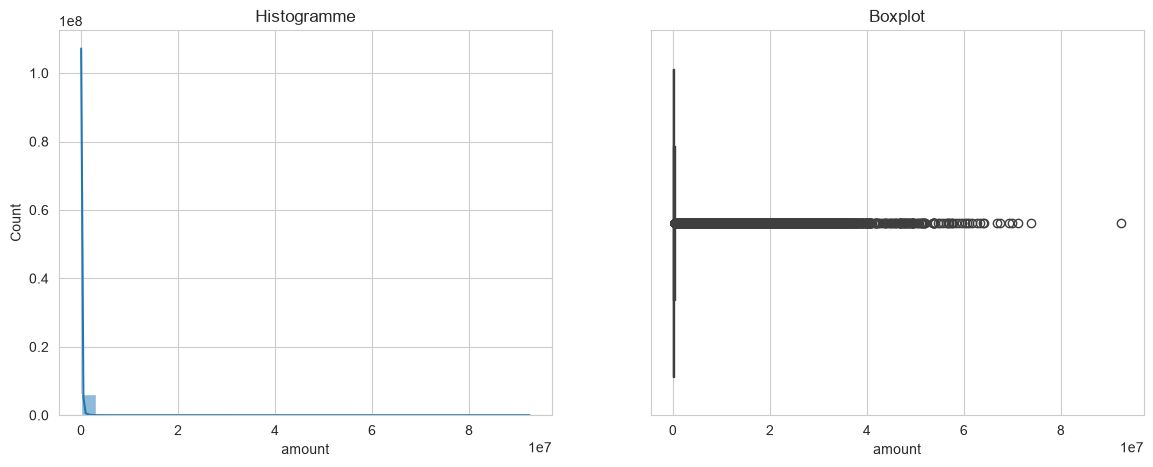

In [93]:
#histogramme et boxplot de la variable amount
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, position 1
sns.histplot(df['amount'], bins=30, kde=True)
plt.title("Histogramme")

plt.subplot(1, 2, 2)  # position 2
sns.boxplot(x=df['amount'])
plt.title("Boxplot")

plt.show()

analyse de la variable oldbalanceOrg

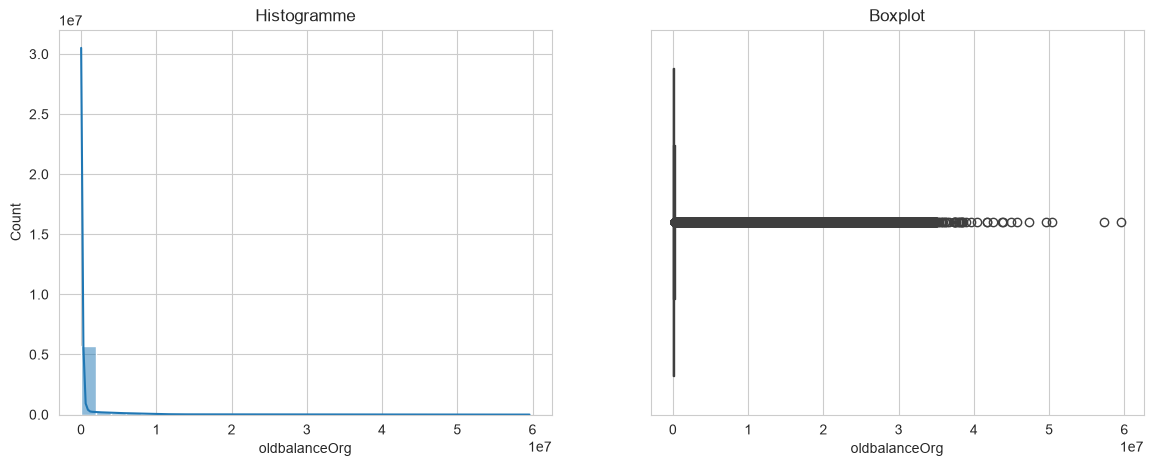

In [92]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, position 1
sns.histplot(df['oldbalanceOrg'], bins=30, kde=True)
plt.title("Histogramme")

plt.subplot(1, 2, 2)  # position 2
sns.boxplot(x=df['oldbalanceOrg'])
plt.title("Boxplot")

plt.show()

analyse de newbalanceOrig

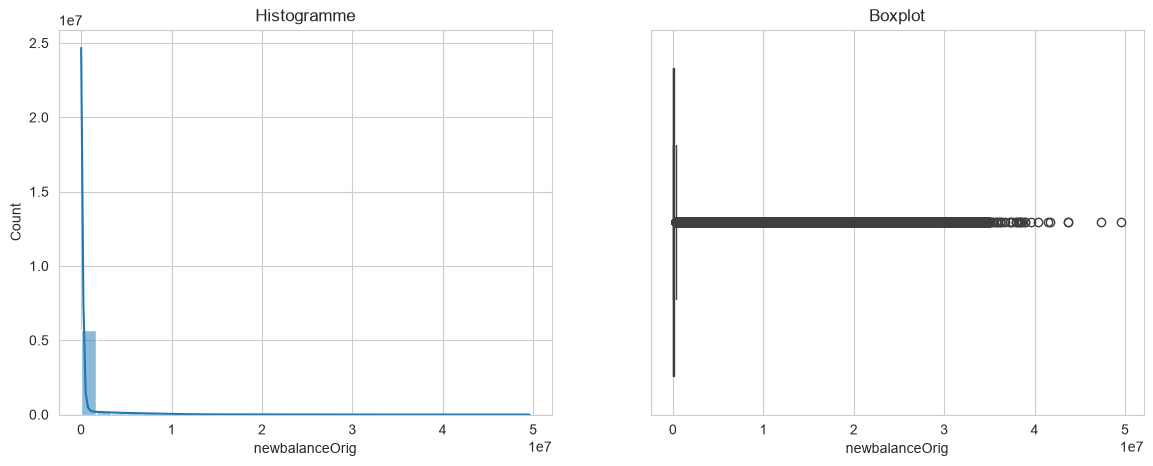

In [91]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, position 1
sns.histplot(df['newbalanceOrig'], bins=30, kde=True)
plt.title("Histogramme")

plt.subplot(1, 2, 2)  # position 2
sns.boxplot(x=df['newbalanceOrig'])
plt.title("Boxplot")

plt.show()

analyse de la variable oldbalanceDest

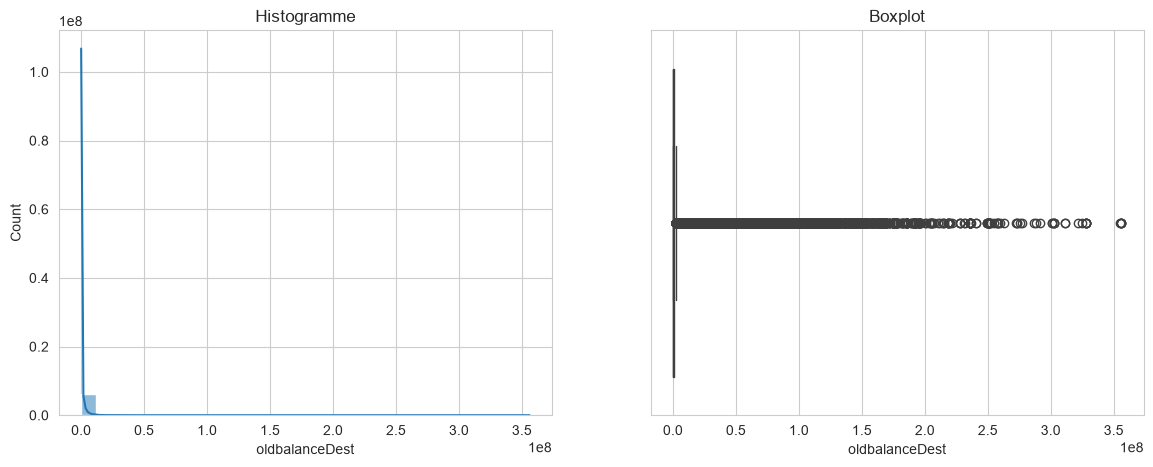

In [90]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, position 1
sns.histplot(df['oldbalanceDest'], bins=30, kde=True)
plt.title("Histogramme")

plt.subplot(1, 2, 2)  # position 2
sns.boxplot(x=df['oldbalanceDest'])
plt.title("Boxplot")

plt.show()

analyse de la variable newbalanceDest

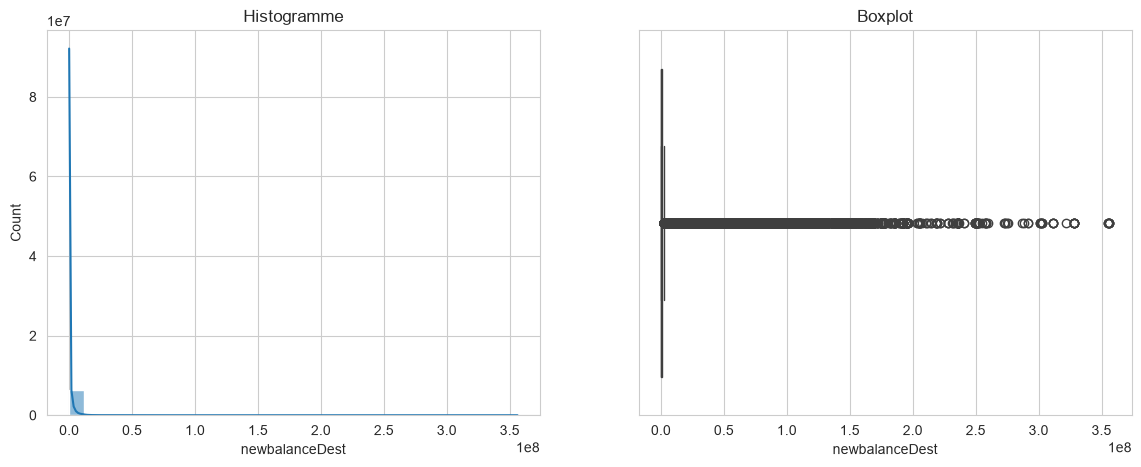

In [89]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, position 1
sns.histplot(df['newbalanceDest'], bins=30, kde=True)
plt.title("Histogramme")

plt.subplot(1, 2, 2)  # position 2
sns.boxplot(x=df['newbalanceDest'])
plt.title("Boxplot")

plt.show()

Détection des valeurs aberrantes

In [82]:
#fonction pour calculer le IQR
def borne_inf_sup(df, donnee):
  q1 = df[donnee].quantile(0.25)
  q3 = df[donnee].quantile(0.75)
  iqr = q3 - q1
  borne_inf = q1 - 1.5*iqr
  borne_sup = q3 + 1.5*iqr
  if (borne_inf < 0):
    borne_inf = 0
  return borne_inf, borne_sup

In [83]:
borne_inf_montant, borne_sup_montant = borne_inf_sup(df, 'amount')
borne_inf_oldbalanceOrg, borne_sup_oldbalanceOrg = borne_inf_sup(df, 'oldbalanceOrg')
borne_inf_newbalanceOrig, borne_sup_newbalanceOrig = borne_inf_sup(df, 'newbalanceOrig')
borne_inf_oldbalanceDest, borne_sup_oldbalanceDest = borne_inf_sup(df, 'oldbalanceDest')
borne_inf_newbalanceDest, borne_sup_newbalanceDest = borne_inf_sup(df, 'newbalanceDest')
print("Bornes pour le montant : [", borne_inf_montant, ",", borne_sup_montant, "]")
print("Bornes pour oldbalanceOrg : [", borne_inf_oldbalanceOrg, ",", borne_sup_oldbalanceOrg, "]")
print("Bornes pour newbalanceOrig : [", borne_inf_newbalanceOrig, ",", borne_sup_newbalanceOrig, "]")
print("Bornes pour oldbalanceDest : [", borne_inf_oldbalanceDest, ",", borne_sup_oldbalanceDest, "]")
print("Bornes pour newbalanceDest : [", borne_inf_newbalanceDest, ",", borne_sup_newbalanceDest, "]")

Bornes pour le montant : [ 0 , 501719.33875 ]
Bornes pour oldbalanceOrg : [ 0 , 268287.9375 ]
Bornes pour newbalanceOrig : [ 0 , 360646.025 ]
Bornes pour oldbalanceDest : [ 0 , 2357591.76875 ]
Bornes pour newbalanceDest : [ 0 , 2779773.125 ]


Analyse bivariée et multivariée

<Axes: >

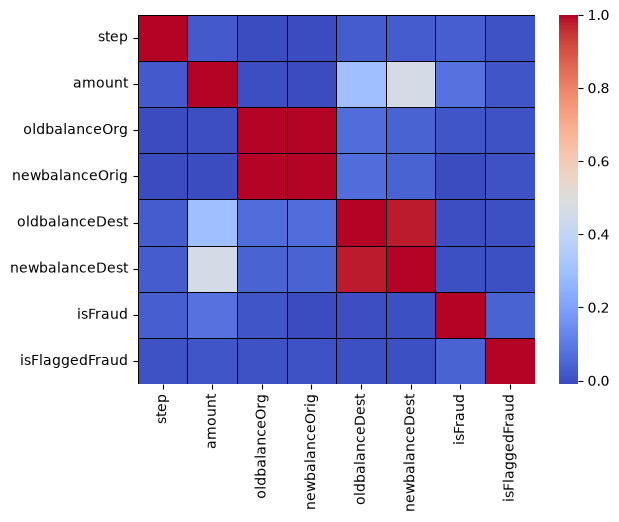

In [72]:
corr = df.drop(columns=['type', 'nameOrig', 'nameDest']).corr()
sns.heatmap(corr, cmap='coolwarm', linewidth=0.5, linecolor='black')

nuage de point entre les variables

In [124]:
df['amount'].max()

np.float64(92445516.64)

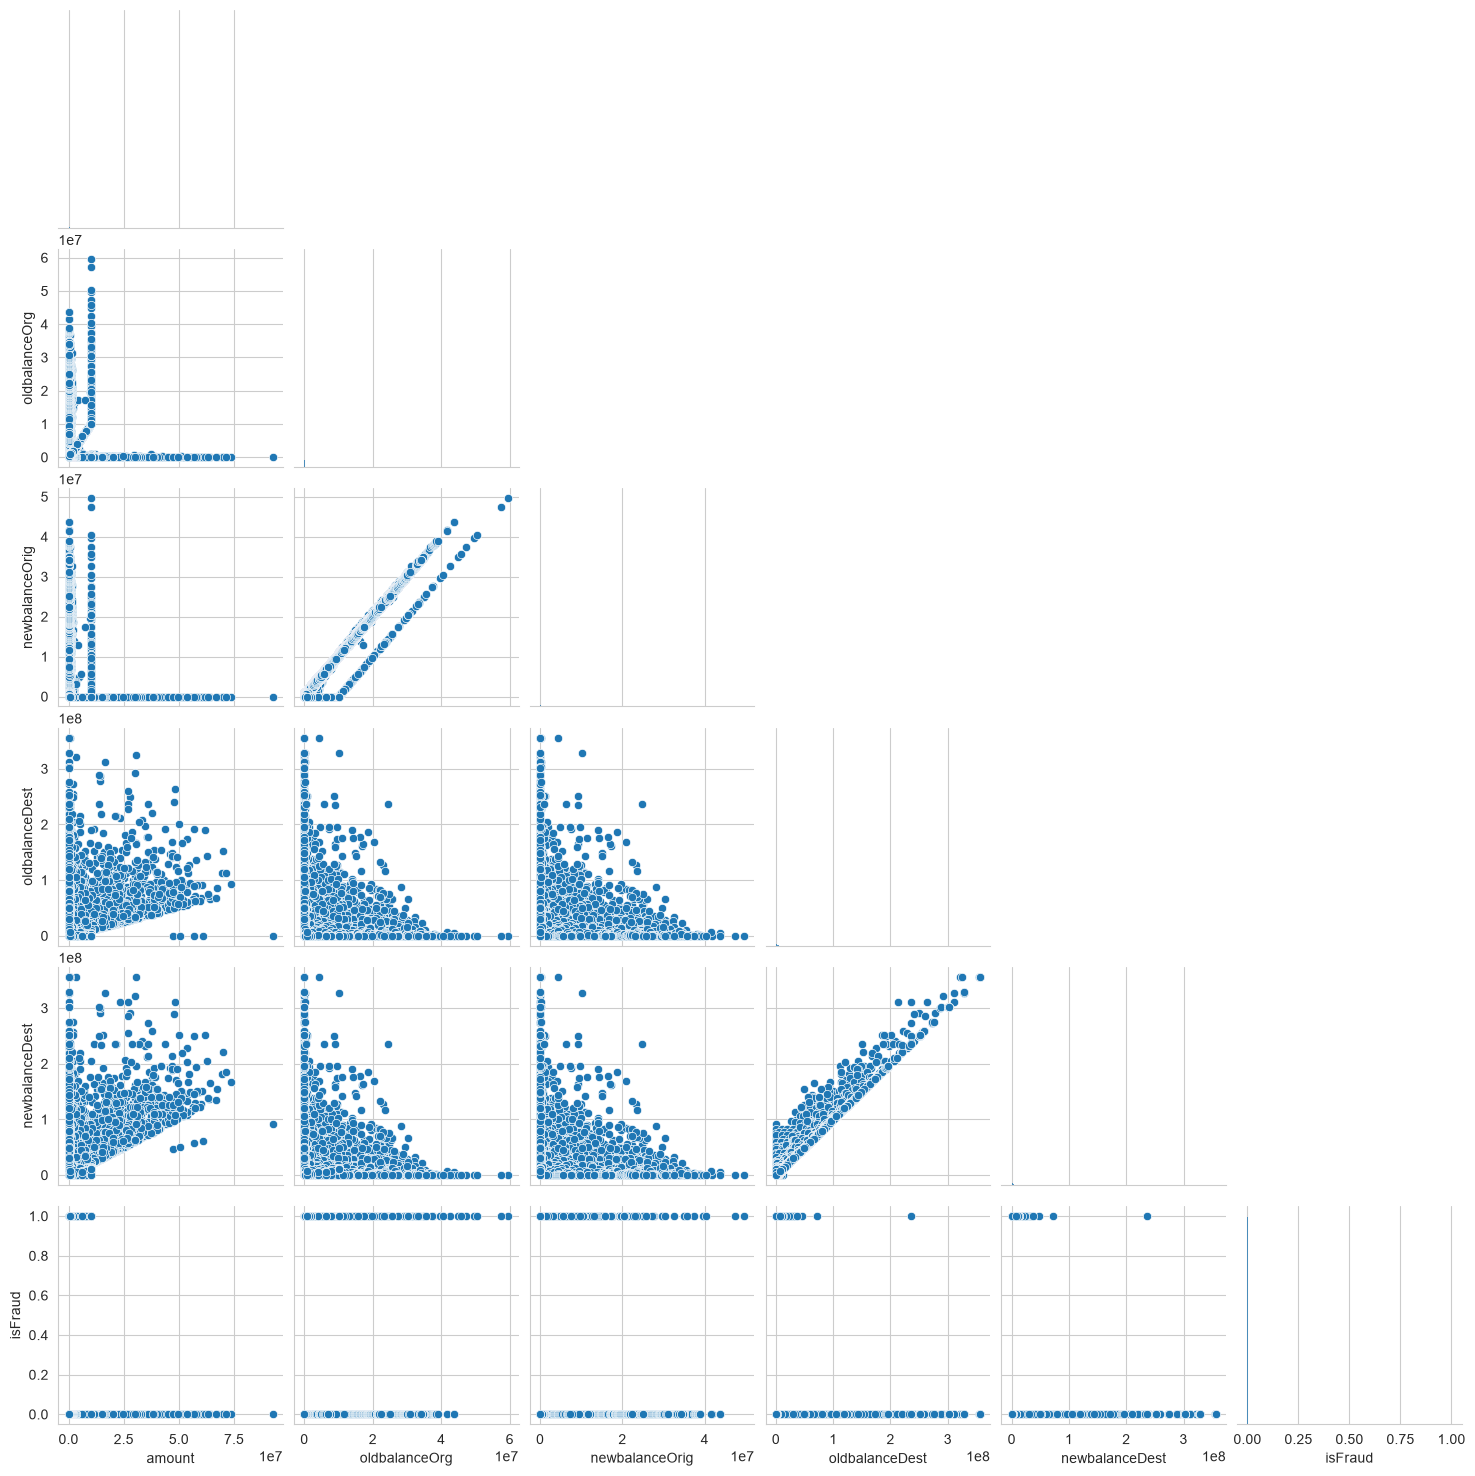

In [79]:
sns.set_style("whitegrid")

# On sélectionne uniquement les colonnes numériques
df_numeric = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']]

# Trace la matrice complète de nuages de points d'un seul coup
# (Optionnel : tu peux ajouter hue='isFraud' pour colorer les points !)
sns.pairplot(df_numeric, corner=True)

plt.show()

<Axes: title={'center': 'Type de transaction pour les transactions frauduleuses'}, xlabel='type'>

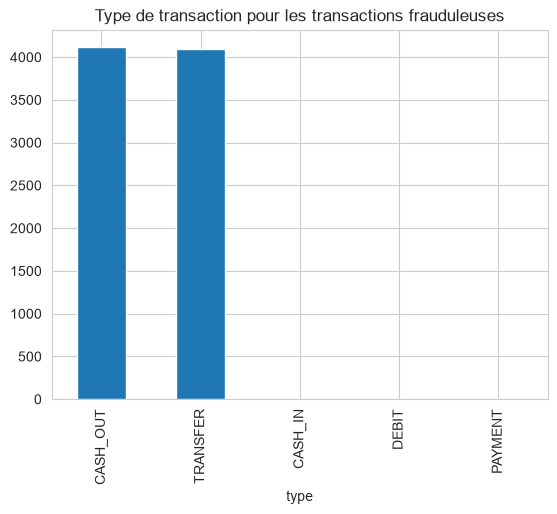

In [80]:
#detection du type pour les transactions frauduleuses
df[df["isFraud"] == True]["type"].value_counts().plot(kind='bar', title='Type de transaction pour les transactions frauduleuses')

Etude des transactions frauduleuses

In [115]:
# On isole uniquement les transactions frauduleuses
df_fraude = df[df["isFraud"] == 1]

# résumé statistique des transactions frauduleuses
df_fraude.drop(columns=['isFraud', 'isFlaggedFraud']).describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,"8,213.00","8,213.00","8,213.00","8,213.00","8,213.00","8,213.00"
mean,368.41,"1,467,967.30","1,649,667.61","192,392.63","544,249.62","1,279,707.62"
std,216.39,"2,404,252.95","3,547,719.44","1,965,666.46","3,336,420.95","3,908,816.53"
min,1.00,0.00,0.00,0.00,0.00,0.00
25%,181.00,"127,091.33","125,822.44",0.00,0.00,0.00
50%,367.00,"441,423.44","438,983.45",0.00,0.00,"4,676.42"
75%,558.00,"1,517,771.48","1,517,771.48",0.00,"147,828.66","1,058,725.22"
max,743.00,"10,000,000.00","59,585,040.37","49,585,040.37","236,230,516.82","236,726,494.66"


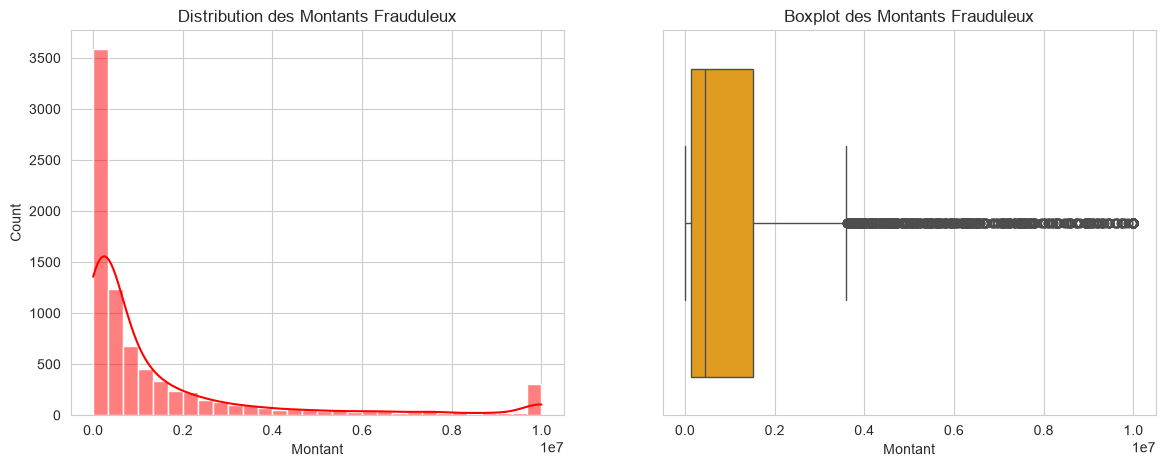

In [87]:
plt.figure(figsize=(14, 5))

# Gauche : L'histogramme pour voir la forme globale
plt.subplot(1, 2, 1)
sns.histplot(df_fraude["amount"], bins=30, kde=True, color="red")
plt.title("Distribution des Montants Frauduleux")
plt.xlabel("Montant")

# Droite : Le boxplot pour repérer l'écart-type et les valeurs extrêmes
plt.subplot(1, 2, 2)
sns.boxplot(x=df_fraude["amount"], color="orange")
plt.title("Boxplot des Montants Frauduleux")
plt.xlabel("Montant")

plt.show()

In [88]:
borne_inf_montantFR, borne_sup_montantFR = borne_inf_sup(df_fraude, 'amount')
print("Bornes pour les montants frauduleux : [", borne_inf_montantFR, ",", borne_sup_montantFR, "]")


Bornes pour les montants frauduleux : [ 0 , 3603791.705 ]


<Axes: title={'center': 'Montant moyen des transactions en fonction de la fraude'}, xlabel='isFraud'>

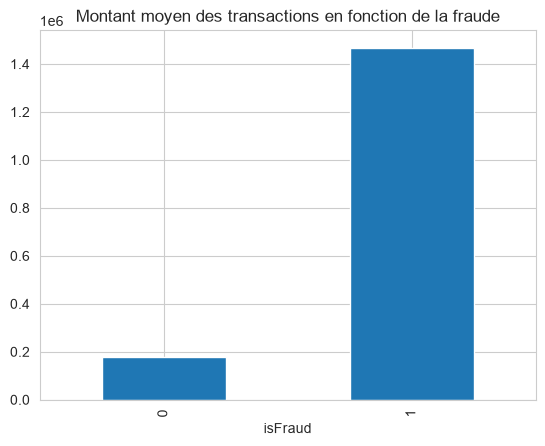

In [85]:
df.groupby('isFraud')['amount'].mean().plot(kind='bar', title='Montant moyen des transactions en fonction de la fraude')

In [105]:
df_fraude.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
251,1,TRANSFER,"2,806.00",C1420196421,"2,806.00",0.00,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,"2,806.00",C2101527076,"2,806.00",0.00,C1007251739,"26,202.00",0.00,1,0
680,1,TRANSFER,"20,128.00",C137533655,"20,128.00",0.00,C1848415041,0.00,0.00,1,0
681,1,CASH_OUT,"20,128.00",C1118430673,"20,128.00",0.00,C339924917,"6,268.00","12,145.85",1,0
724,1,CASH_OUT,"416,001.33",C749981943,0.00,0.00,C667346055,102.00,"9,291,619.62",1,0
969,1,TRANSFER,"1,277,212.77",C1334405552,"1,277,212.77",0.00,C431687661,0.00,0.00,1,0
970,1,CASH_OUT,"1,277,212.77",C467632528,"1,277,212.77",0.00,C716083600,0.00,"2,444,985.19",1,0
1115,1,TRANSFER,"35,063.63",C1364127192,"35,063.63",0.00,C1136419747,0.00,0.00,1,0


In [123]:
# Calcule la proportion de fraudes qui laissent le compte à 0
pourcentage_vides = (df_fraude['newbalanceOrig'] == 0).mean() * 100

print(f"Pourcentage de comptes vidés lors d'une fraude : {pourcentage_vides:.2f}%")

Pourcentage de comptes vidés lors d'une fraude : 98.05%


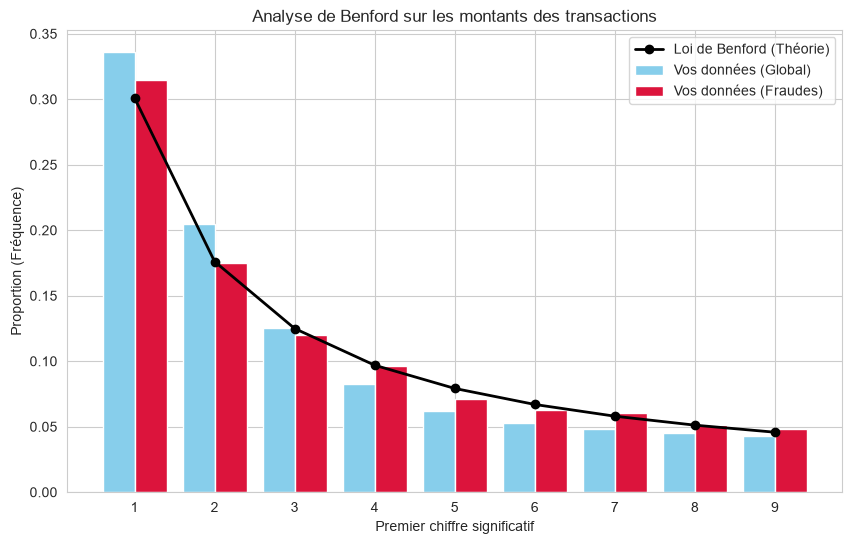

In [111]:
# 1. Fonction pour extraire le premier chiffre significatif (ex: 0.05 -> 5, 450 -> 4)
def get_first_digit(series):
    # On convertit en texte, on nettoie les espaces/signes et on prend le premier caractère non nul
    digits = (
        series.astype(str)
        .str.replace(r"^[0.\s\-]+", "", regex=True)
        .str[0]
    )
    # On ne garde que les chiffres valides de 1 à 9
    return pd.to_numeric(digits, errors="coerce").dropna().astype(int)


# 2. Préparation des données réelles
# Premier chiffre pour TOUTES les transactions
df_clean = df[df["amount"] > 0]
digits_all = get_first_digit(df_clean["amount"])
counts_all = digits_all.value_counts(normalize=True).sort_index()

# Premier chiffre uniquement pour les FRAUDES
df_fraud = df_clean[df_clean["isFraud"] == 1]
if not df_fraud.empty:
    digits_fraud = get_first_digit(df_fraud["amount"])
    counts_fraud = digits_fraud.value_counts(normalize=True).sort_index()
else:
    counts_fraud = None

# 3. Distribution théorique de Benford
chiffres = np.arange(1, 10)
benford_theorique = np.log10(1 + 1 / chiffres)

# 4. Traçage du graphique
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Courbe théorique de Benford
plt.plot(
    chiffres,
    benford_theorique,
    marker="o",
    linewidth=2,
    color="black",
    label="Loi de Benford (Théorie)",
    zorder=3,
)

# Barres pour tes données globales
plt.bar(
    counts_all.index - 0.2,
    counts_all.values,
    width=0.4,
    color="skyblue",
    label="Vos données (Global)",
)

# Barres pour les fraudes (si elles existent)
if counts_fraud is not None:
    plt.bar(
        counts_fraud.index + 0.2,
        counts_fraud.values,
        width=0.4,
        color="crimson",
        label="Vos données (Fraudes)",
    )

plt.xticks(chiffres)
plt.xlabel("Premier chiffre significatif")
plt.ylabel("Proportion (Fréquence)")
plt.title("Analyse de Benford sur les montants des transactions")
plt.legend()
plt.show()